In [1]:
import os

**Dataset Link**
https://www.kaggle.com/datasets/mzohaibzeeshan/google-stock-price-data-2020-2025-googl

In [ ]:
import wanings
warnings.filterwarnings("ignore")

In [2]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import randint
import optuna

In [3]:
# Import the dataset and see the basic information about it
df = pd.read_csv("/kaggle/input/google-stock-price-data-2020-2025-googl/googl_data_2020_2025.csv")
df.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-02 00:00:00+00:00,68.18682098,68.43399811,68.43399811,67.32450104,67.42050171,27278000
3,2020-01-03 00:00:00+00:00,67.83010101,68.0759964,68.6875,67.36599731,67.40000153,23408000
4,2020-01-06 00:00:00+00:00,69.63805389,69.89050293,69.91600037,67.55000305,67.58149719,46768000


In [4]:
# Remove the unwanted rows or columns
df = df.drop([0,1]).reset_index(drop=True)

In [5]:
# Remove the unwanted columns 
df.drop(columns=['Price'], inplace=True)

In [6]:
# Convert all the object features into nunerical values
df = df.astype(float)

In [7]:
print(df.dtypes)
print(df.isnull().sum())

Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume       float64
dtype: object
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [8]:
# Copy the dataframe to original and duplicate
df_original = df.copy()
df_copy = df.copy()
print("Data copied to original and copied successfully!")

Data copied to original and copied successfully!


In [59]:
df_copy.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [9]:
# Encode the categorical values
import pickle
encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        encoder = LabelEncoder()
        df[col]= encoder.fit_transform(df[col])
        encoders[col] = encoder

with open('stock_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Encoders dumped successfully!")

Encoders dumped successfully!


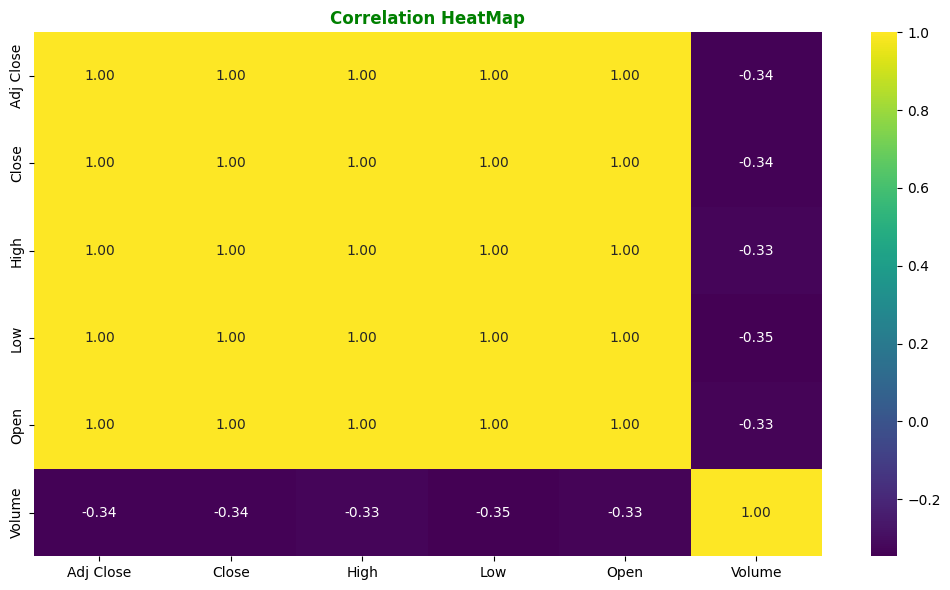

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


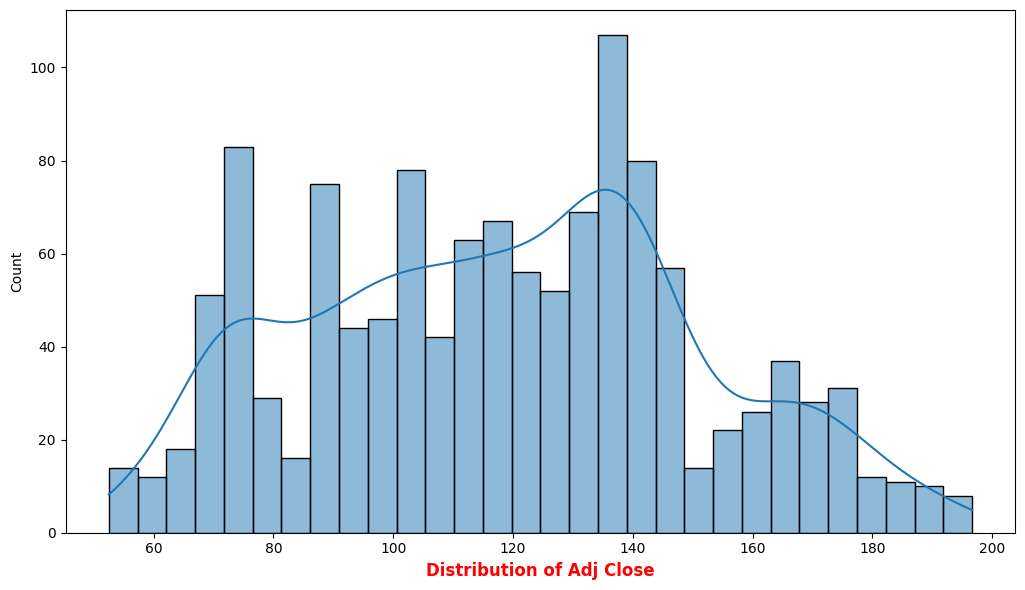

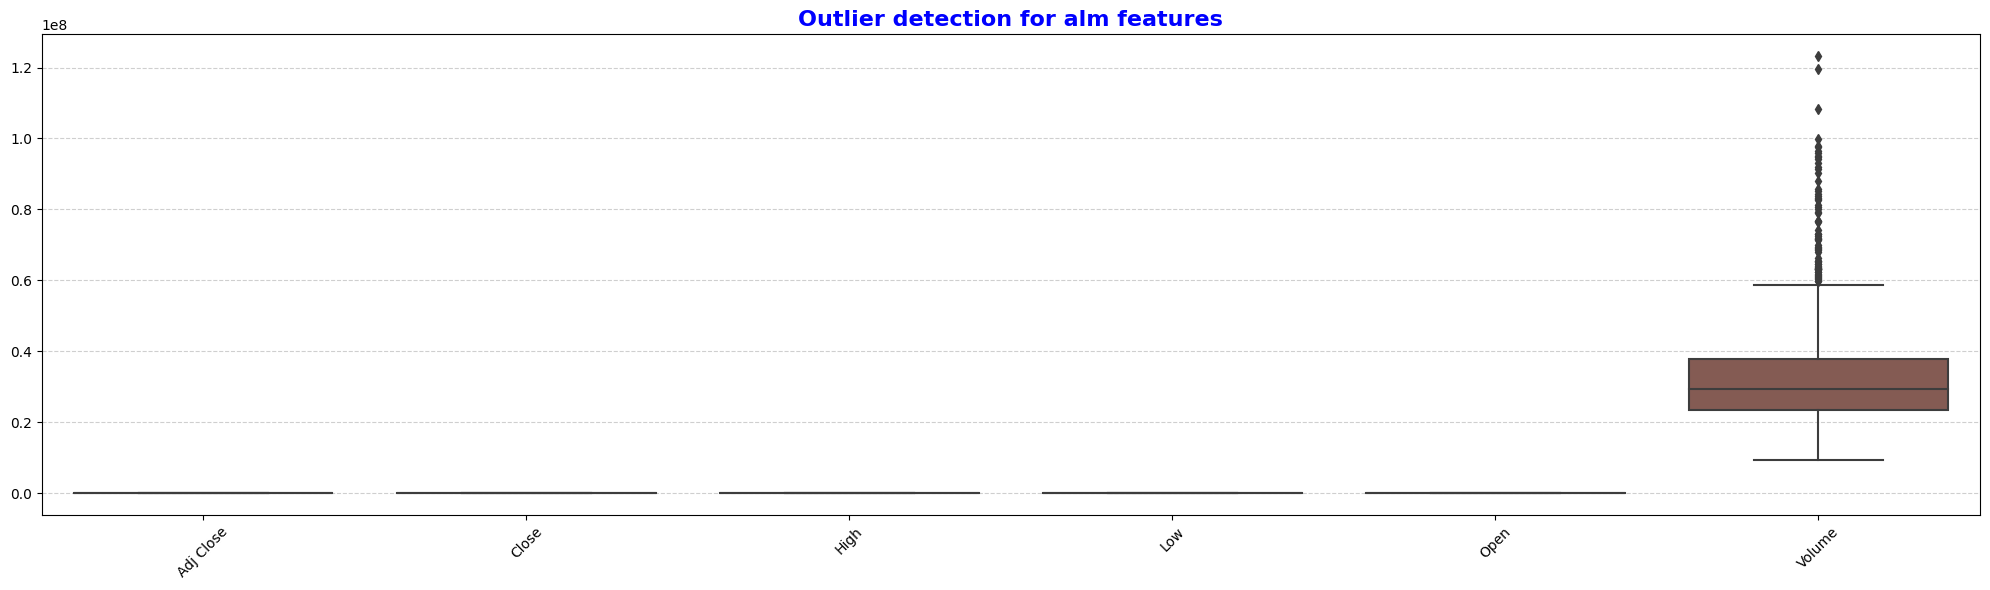

In [10]:
# Correlation map
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.heatmap(df_copy.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation HeatMap", color='green', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution Table of Close
plt.figure(figsize=(20,6))
plt.subplot(1,2,2)
sns.histplot(df_copy['Adj Close'], kde=True, bins=30)
plt.xlabel("Distribution of Adj Close", color='red', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Outliers detection
plt.figure(figsize=(20,6))
sns.boxplot(data=df)
plt.title("Outlier detection for alm features", fontsize=16, color='blue', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
# Split features & target
X = df_copy.drop(columns=['Adj Close'])
y = df_copy['Adj Close']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
def evoluate(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return mse, mae, rmse, r2

In [12]:
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.svm import SVR

# Optuna objective function
def objective(trial):
    params = {
        'C': trial.suggest_loguniform('C', 0.001, 1),
        'epsilon': trial.suggest_loguniform('epsilon', 0.001, 1.0),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel': trial.suggest_categorical('kernel', ['rbf'])
    }

    model = SVR(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, n_jobs=-1, verbose=2)
    return np.mean(score)

# Optuna Optimzation 
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best Params : ", study.best_params)
print("Best R2 score : ", study.best_value)

# Train final and predict the model
best_svr = SVR(**study.best_params)
best_svr.fit(X_train_scaled, y_train)

y_pred = best_svr.predict(X_test_scaled)

[I 2025-10-30 16:40:35,017] A new study created in memory with name: no-name-e528f9ea-3c2b-47f3-882f-4009db78460b


  0%|          | 0/30 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


[I 2025-10-30 16:40:37,181] Trial 0 finished with value: 0.08341874278550603 and parameters: {'C': 0.010048262852424389, 'epsilon': 0.0027364037134653104, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 0 with value: 0.08341874278550603.
[I 2025-10-30 16:40:37,332] Trial 1 finished with value: 0.518163059692845 and parameters: {'C': 0.07546891080412155, 'epsilon': 0.011576840380565495, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 1 with value: 0.518163059692845.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


...

[I 2025-10-30 16:40:40,233] Trial 24 finished with value: 0.8267377884228587 and parameters: {'C': 0.26690234354860176, 'epsilon': 0.06250866284243142, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 23 with value: 0.9543637671874745.
[I 2025-10-30 16:40:40,369] Trial 25 finished with value: 0.9248468573906422 and parameters: {'C': 0.5922195553352165, 'epsilon': 0.03012819757415931, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 23 with value: 0.9543637671874745.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


[I 2025-10-30 16:40:40,508] Trial 26 finished with value: 0.8894716042756009 and parameters: {'C': 0.40581414395711657, 'epsilon': 0.0808617988763509, 'gamma': 'auto', 'kernel': 'rbf'}. Best is trial 23 with value: 0.9543637671874745.
[I 2025-10-30 16:40:40,635] Trial 27 finished with value: 0.5786995142797894 and parameters: {'C': 0.09052497363726528, 'epsilon': 0.5676082671475348, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 23 with value: 0.9543637671874745.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished


[I 2025-10-30 16:40:40,762] Trial 28 finished with value: 0.7733083864443807 and parameters: {'C': 0.2026933161912162, 'epsilon': 0.11219082856585916, 'gamma': 'auto', 'kernel': 'rbf'}. Best is trial 23 with value: 0.9543637671874745.
[I 2025-10-30 16:40:40,898] Trial 29 finished with value: 0.12140414591241222 and parameters: {'C': 0.014626384911509516, 'epsilon': 0.020187041941382697, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 23 with value: 0.9543637671874745.
Best Params :  {'C': 0.9851659335720859, 'epsilon': 0.07617509557769304, 'gamma': 'scale', 'kernel': 'rbf'}
Best R2 score :  0.9543637671874745


In [15]:
# Evolution metrics
print("Evolution metrics : ", evoluate(y_test, y_pred))

Evolution metrics :  (85.55718090607817, 3.3008525369807145, 9.249712476941008, 0.9188152655640136)


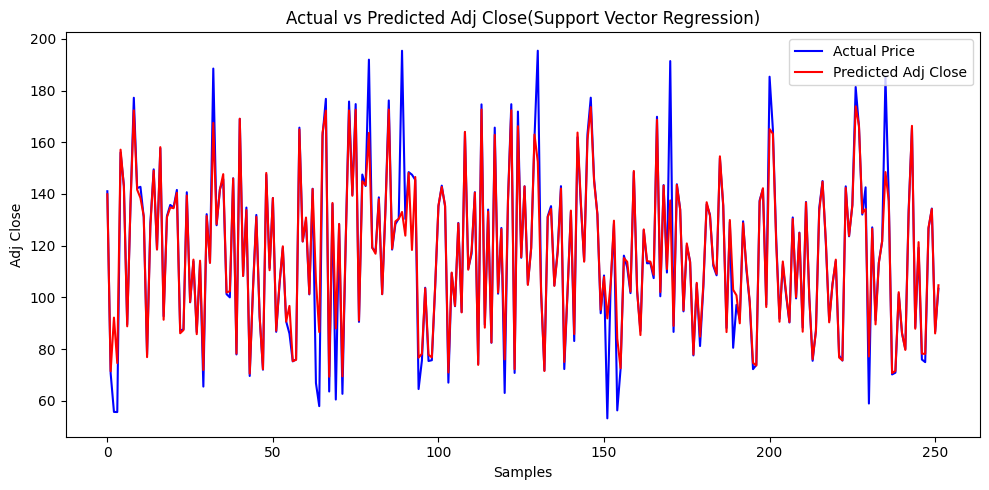

In [16]:
# Plot for the actual vs predicted

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Adj Close', color='red')
plt.title('Actual vs Predicted Adj Close(Support Vector Regression)')
plt.xlabel('Samples')
plt.ylabel('Adj Close')
plt.tight_layout()
plt.legend()
plt.show()

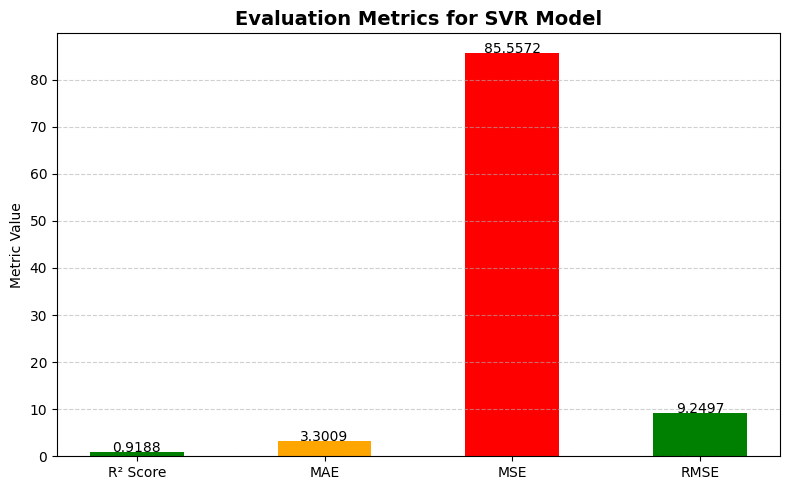

In [16]:
# Plot Evaluation Metrics Graph

# Create a dictionary of metrics
metrics = {
    'R² Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE':np.sqrt(mean_squared_error(y_test, y_pred))
}

# Plot
plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values(), color=['green', 'orange', 'red'], width=0.5)
plt.title('Evaluation Metrics for SVR Model', fontsize=14, fontweight='bold')
plt.ylabel('Metric Value')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate values on bars
for i, (key, value) in enumerate(metrics.items()):
    plt.text(i, value + 0.01, f"{value:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Residual Distribution')

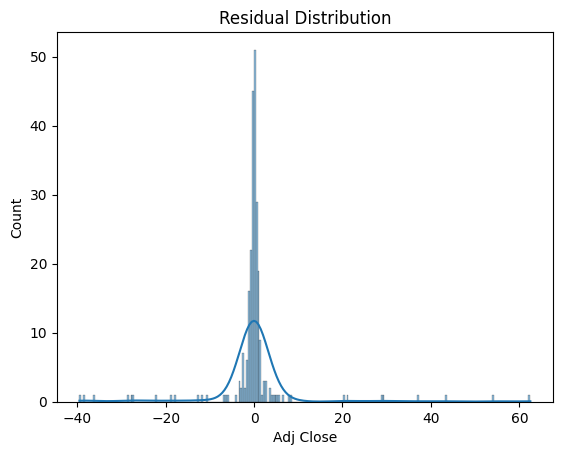

In [17]:
# Residual analysis
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

In [20]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_parallel_coordinate,
    plot_contour,
    plot_edf
)

# Basic summary
best_params = study.best_params
best_score = study.best_value

print("Best Parameters:", best_params)
print("Best CV R² Score:", best_score)

plots = {
    "optimization_history": plot_optimization_history(study),
    "param_importances": plot_param_importances(study),
    "parallel_coordinate": plot_parallel_coordinate(study),
    "contour": plot_contour(study),
    "slice": plot_slice(study),
    "edf": plot_edf(study)
}

# Show the plots
for name, fig in plots.items():
    fig.show()

Best Parameters: {'C': 0.9851659335720859, 'epsilon': 0.07617509557769304, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV R² Score: 0.9543637671874745


[W 2025-10-30 16:43:05,084] Param kernel unique value length is less than 2.
[W 2025-10-30 16:43:05,085] Param kernel unique value length is less than 2.
[W 2025-10-30 16:43:05,086] Param kernel unique value length is less than 2.
[W 2025-10-30 16:43:05,087] Param kernel unique value length is less than 2.
[W 2025-10-30 16:43:05,087] Param kernel unique value length is less than 2.
[W 2025-10-30 16:43:05,088] Param kernel unique value length is less than 2.


In [21]:
from sklearn.pipeline import make_pipeline
import joblib

# Create pipeline
pipe = make_pipeline(StandardScaler(), best_svr)
pipe.fit(X_train, y_train)

# Save
joblib.dump(pipe, "/kaggle/working/svr_regressor_pipeline.pkl")
print("Model saved successfully!")

Model saved successfully!
